#                                                     **ONLINE VS IN-STORE SHOPPING BEHAVIOUR DATASET**

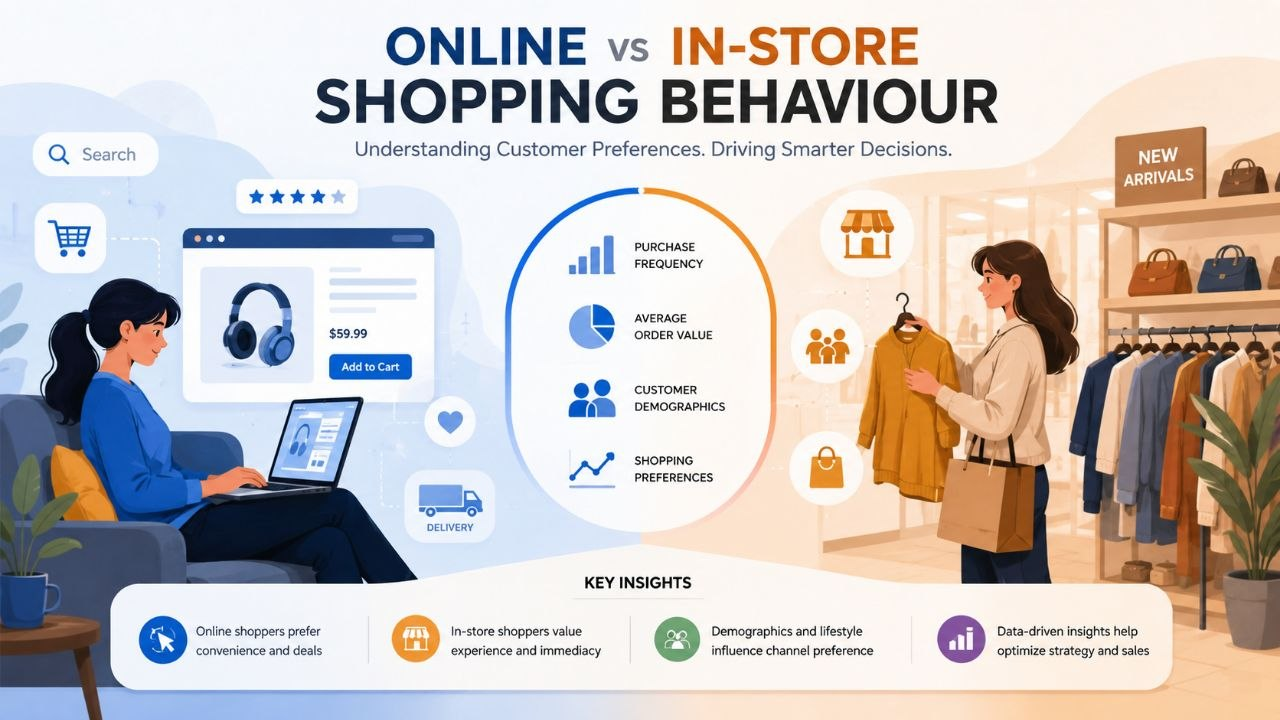

## DATA DESCRIPTION

The increasing use of digital technology has changed the way people shop. Consumers now prefer online shopping, in-store shopping, or a combination of both depending on convenience, spending habits, and personal preferences. This project analyzes an **Online vs In-Store Shopping Behavior Dataset** to understand customer shopping patterns and predict shopping preferences using data science and machine learning techniques.

The dataset contains **11,789 records** and **25 features** related to customer demographics, internet usage, shopping behavior, spending patterns, and consumer preferences.

### **Features Included in the Dataset**

* **Age** – Age of the customer
* **Monthly Income** – Monthly income of the customer
* **Daily Internet Hours** – Average daily internet usage hours
* **Smartphone Usage Years** – Number of years using smartphones
* **Social Media Hours** – Daily social media usage hours
* **Online Payment Trust Score** – Trust level in online payment systems
* **Tech Savvy Score** – Customer’s technology knowledge score
* **Monthly Online Orders** – Number of online orders placed monthly
* **Monthly Store Visits** – Number of physical store visits per month
* **Average Online Spend** – Average spending on online shopping
* **Average Store Spend** – Average spending in physical stores
* **Discount Sensitivity** – Sensitivity toward discounts and offers
* **Return Frequency** – Frequency of product returns
* **Average Delivery Days** – Average product delivery time
* **Delivery Fee Sensitivity** – Sensitivity towards delivery charges
* **Free Return Importance** – Importance given to free return policies
* **Product Availability Online** – Availability of products online
* **Impulse Buying Score** – Impulsive purchasing tendency
* **Need Touch Feel Score** – Preference to physically inspect products before buying
* **Brand Loyalty Score** – Loyalty towards specific brands
* **Environmental Awareness** – Awareness about environmental impacts
* **Time Pressure Level** – Customer’s time constraints during shopping
* **Gender** – Gender of the customer
* **City Tier** – Tier classification of the customer’s city
* **Shopping Preference** – Target variable indicating Online, Store, or Hybrid shopping preference

    0--->Hybrid
    1--->Online
    2--->Store

Using this dataset, the project applies data preprocessing, exploratory data analysis (EDA), feature analysis, and machine learning models to identify patterns in consumer behavior. The findings of this project can help businesses understand customer preferences better and make data-driven decisions to improve both online and offline shopping experiences.

**DATA LOADING**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

In [41]:
df=pd.read_csv("/content/drive/MyDrive/online vs store shopping dataset.csv",nrows=5000)
df

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,42,89442,8.6,12,1.7,10,2,1,7,107688,...,9,3,7,4,5,6,2,Other,Tier 1,Hybrid
4996,39,167890,6.0,7,3.3,7,8,0,7,85455,...,2,7,6,10,1,10,2,Female,Tier 1,Store
4997,48,189318,5.6,12,3.6,5,4,13,6,10481,...,1,1,2,8,1,2,8,Female,Tier 3,Store
4998,34,70598,2.9,12,0.0,5,6,43,9,74926,...,4,9,9,1,8,4,10,Female,Tier 2,Online


In [3]:
df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


In [4]:
df.tail()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
4995,42,89442,8.6,12,1.7,10,2,1,7,107688,...,9,3,7,4,5,6,2,Other,Tier 1,Hybrid
4996,39,167890,6.0,7,3.3,7,8,0,7,85455,...,2,7,6,10,1,10,2,Female,Tier 1,Store
4997,48,189318,5.6,12,3.6,5,4,13,6,10481,...,1,1,2,8,1,2,8,Female,Tier 3,Store
4998,34,70598,2.9,12,0.0,5,6,43,9,74926,...,4,9,9,1,8,4,10,Female,Tier 2,Online
4999,72,148726,4.4,7,4.8,10,5,14,1,44288,...,5,8,7,1,2,10,8,Other,Tier 1,Online


**DATA UNDERSTANDING**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          5000 non-null   int64  
 1   monthly_income               5000 non-null   int64  
 2   daily_internet_hours         5000 non-null   float64
 3   smartphone_usage_years       5000 non-null   int64  
 4   social_media_hours           5000 non-null   float64
 5   online_payment_trust_score   5000 non-null   int64  
 6   tech_savvy_score             5000 non-null   int64  
 7   monthly_online_orders        5000 non-null   int64  
 8   monthly_store_visits         5000 non-null   int64  
 9   avg_online_spend             5000 non-null   int64  
 10  avg_store_spend              5000 non-null   int64  
 11  discount_sensitivity         5000 non-null   int64  
 12  return_frequency             5000 non-null   int64  
 13  avg_delivery_days 

In [6]:
df.describe()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,...,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,48.805600,131465.710000,6.008680,7.570600,2.511660,5.410200,5.567200,24.445800,9.5182,74341.897200,...,4.493000,4.01920,5.475400,5.477800,5.506200,5.561000,5.514000,5.535200,5.422400,5.455400
std,17.906991,68307.760504,1.984094,3.988909,1.263516,2.872836,2.867111,14.452669,5.7395,43072.444835,...,2.873813,1.97869,2.877682,2.872483,2.864263,2.887342,2.892037,2.847452,2.887082,2.868459
min,18.000000,15036.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.0000,529.000000,...,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,71967.250000,4.600000,4.000000,1.600000,3.000000,3.000000,12.000000,5.0000,36486.500000,...,2.000000,2.00000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,49.000000,130464.000000,6.000000,8.000000,2.500000,5.000000,6.000000,25.000000,10.0000,74883.000000,...,4.000000,4.00000,5.000000,5.000000,5.000000,6.000000,5.500000,6.000000,5.000000,5.000000
75%,64.000000,190781.750000,7.400000,11.000000,3.400000,8.000000,8.000000,37.000000,14.0000,111751.500000,...,7.000000,6.00000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,79.000000,249975.000000,12.000000,14.000000,6.000000,10.000000,10.000000,49.000000,19.0000,149939.000000,...,9.000000,7.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


**DATA CLEANING**

In [7]:
df.drop_duplicates()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,42,89442,8.6,12,1.7,10,2,1,7,107688,...,9,3,7,4,5,6,2,Other,Tier 1,Hybrid
4996,39,167890,6.0,7,3.3,7,8,0,7,85455,...,2,7,6,10,1,10,2,Female,Tier 1,Store
4997,48,189318,5.6,12,3.6,5,4,13,6,10481,...,1,1,2,8,1,2,8,Female,Tier 3,Store
4998,34,70598,2.9,12,0.0,5,6,43,9,74926,...,4,9,9,1,8,4,10,Female,Tier 2,Online


In [8]:
df.isna().sum()

,0
age,0
monthly_income,0
daily_internet_hours,0
smartphone_usage_years,0
social_media_hours,0
online_payment_trust_score,0
tech_savvy_score,0
monthly_online_orders,0
monthly_store_visits,0
avg_online_spend,0


In [9]:
df.dtypes

,0
age,int64
monthly_income,int64
daily_internet_hours,float64
smartphone_usage_years,int64
social_media_hours,float64
online_payment_trust_score,int64
tech_savvy_score,int64
monthly_online_orders,int64
monthly_store_visits,int64
avg_online_spend,int64


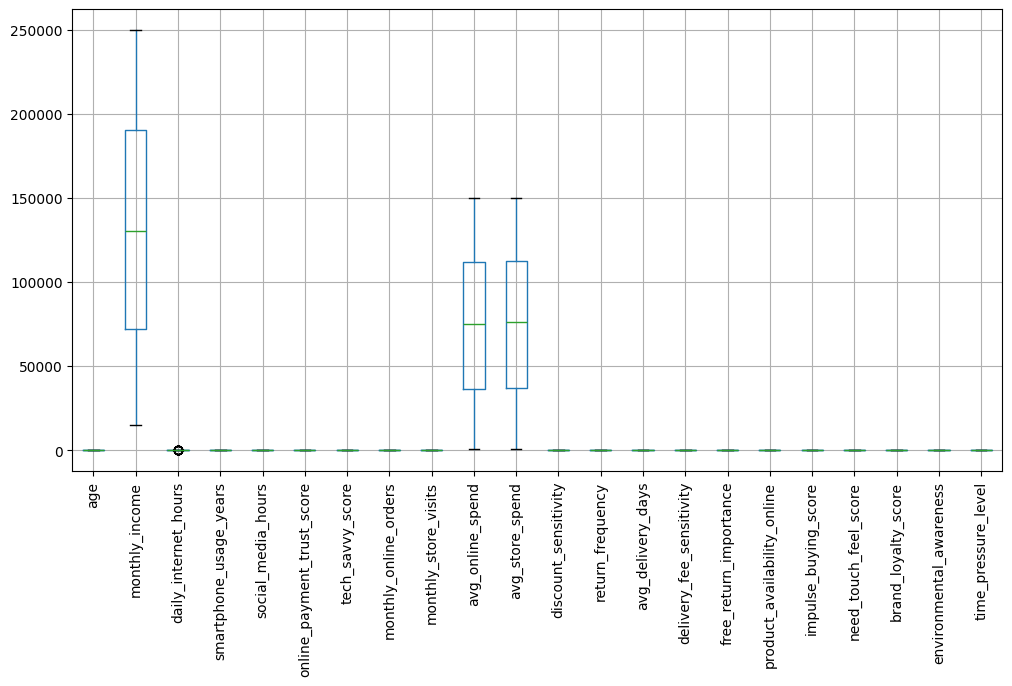

In [10]:
df.boxplot(figsize=(12,6))
plt.xticks(rotation=90)
plt.show()

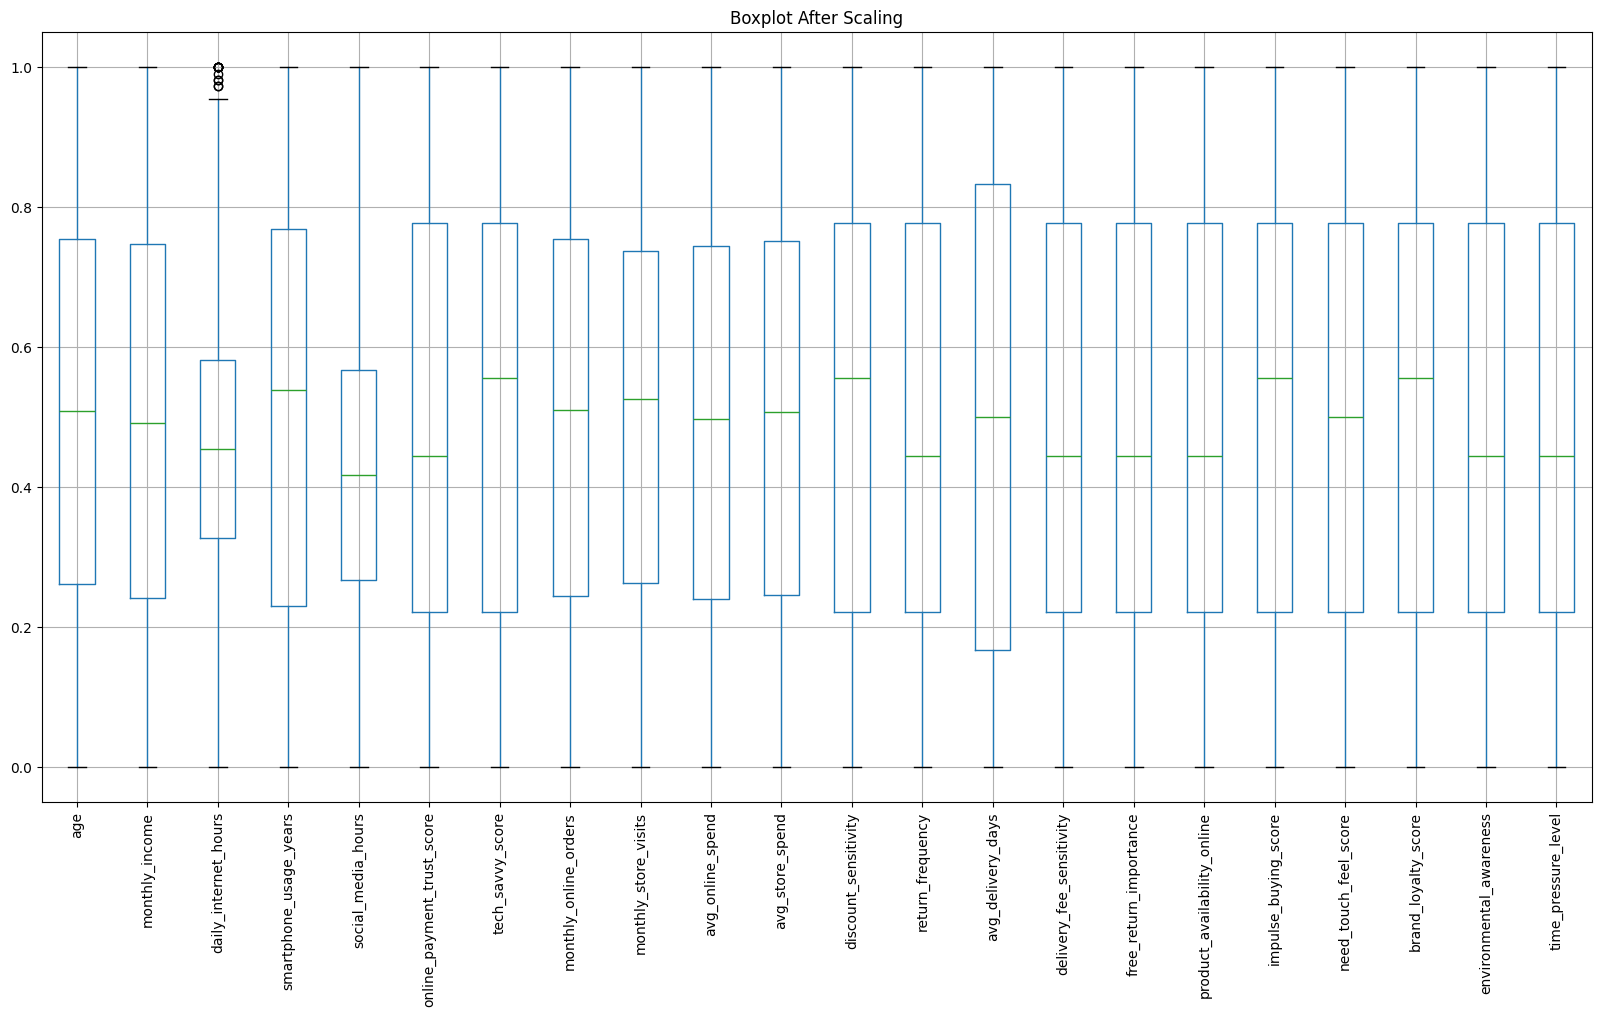

In [11]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[num_cols])
scaled_df = pd.DataFrame(scaled_data, columns=num_cols)
plt.figure(figsize=(20,10))
scaled_df.boxplot(rot=90)
plt.title("Boxplot After Scaling")
plt.show()

**DISTRIBUTION OF CATEGORICAL VARIABLES**

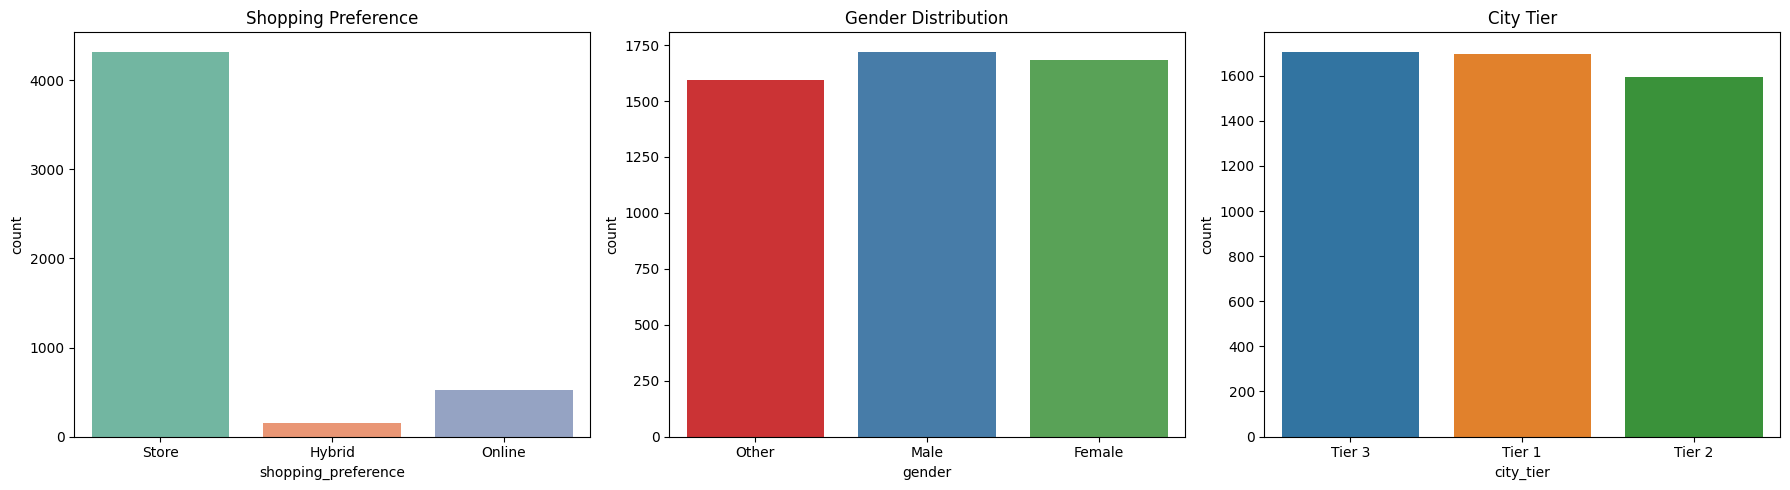

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='shopping_preference',data=df,hue='shopping_preference',palette='Set2',ax=axes[0])
axes[0].set_title("Shopping Preference")

sns.countplot(x='gender',data=df,hue='gender',palette='Set1',ax=axes[1])
axes[1].set_title("Gender Distribution")

sns.countplot(x='city_tier',data=df,hue='city_tier',palette='tab10',ax=axes[2])
axes[2].set_title("City Tier")

plt.tight_layout()
plt.show()

**DISTRIBUTION OF NUMERICAL FEATURES**

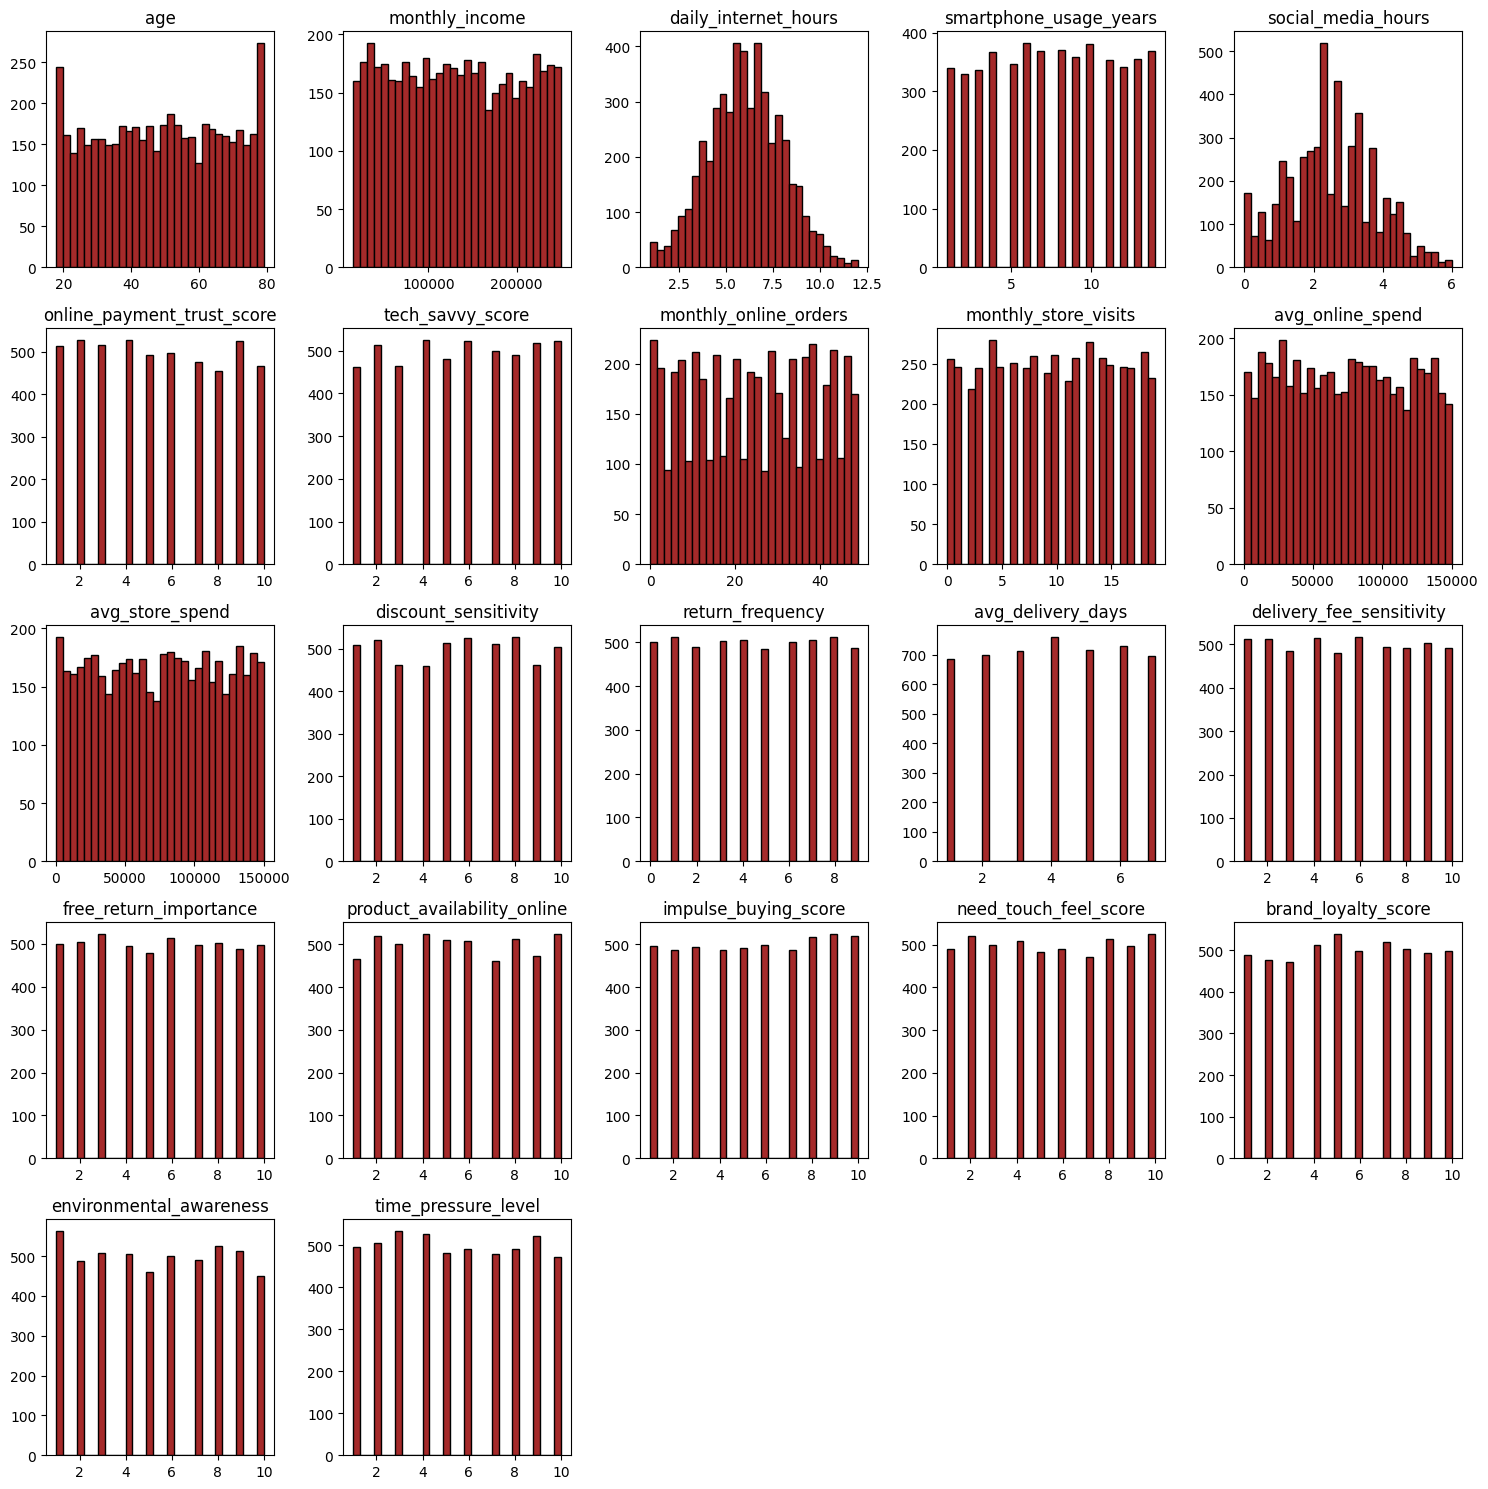

In [13]:
df.hist(figsize=(15,15),bins=30,edgecolor='black',grid=False,color='brown')
plt.tight_layout()
plt.show()

**DISTRIBUTION OF NUMERICAL FEATURES BY SHOPPING PREFERENCE**

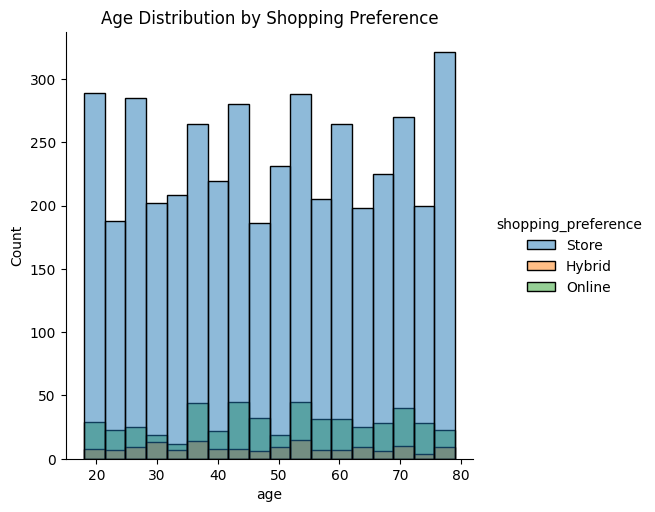

In [14]:
sns.displot(df, x="age", hue="shopping_preference")
plt.title("Age Distribution by Shopping Preference")
plt.show()

**ENCODING CATEGORICAL FEATURES**

In [15]:
df['gender'].unique()

array(['Other', 'Male', 'Female'], dtype=object)

In [16]:
df['city_tier'].unique()

array(['Tier 3', 'Tier 1', 'Tier 2'], dtype=object)

In [17]:
df['shopping_preference'].unique()

array(['Store', 'Hybrid', 'Online'], dtype=object)

In [18]:
le=LabelEncoder()
df['gender']=le.fit_transform(df['gender'])
df['city_tier']=le.fit_transform(df['city_tier'])
df['shopping_preference']=le.fit_transform(df['shopping_preference'])

**FEATURE SELECTION**

In [19]:
df.corr()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
age,1.000000,0.003774,0.015303,0.006745,-0.009497,0.003219,-0.000462,-0.000870,0.009262,0.031468,...,0.024230,-0.004781,-0.010105,0.009107,-0.007108,0.015940,0.000688,0.006637,0.012075,0.002292
monthly_income,0.003774,1.000000,-0.008568,-0.004273,-0.006719,-0.023790,-0.003041,-0.006464,0.014387,0.029211,...,-0.009262,0.010725,0.025497,0.004610,0.014648,0.011097,-0.010141,0.023826,0.007072,-0.010379
daily_internet_hours,0.015303,-0.008568,1.000000,-0.014998,0.018255,0.018369,0.007658,-0.012083,0.014947,0.022426,...,0.008349,0.000452,0.019169,0.009430,0.016595,0.012752,0.014985,-0.007663,0.013539,-0.056826
smartphone_usage_years,0.006745,-0.004273,-0.014998,1.000000,0.014036,-0.027988,-0.026555,0.007482,-0.026164,0.006148,...,0.001691,-0.014238,-0.016127,-0.000042,0.025028,0.002534,-0.010722,-0.007269,0.016001,-0.000636
social_media_hours,-0.009497,-0.006719,0.018255,0.014036,1.000000,0.000705,0.001117,-0.000568,0.008145,0.007478,...,-0.019112,0.011226,0.015106,-0.001411,-0.005210,-0.008101,-0.018542,0.014355,0.002529,0.009638
online_payment_trust_score,0.003219,-0.023790,0.018369,-0.027988,0.000705,1.000000,-0.049188,-0.016329,-0.010407,-0.008208,...,0.003201,0.009063,-0.006213,-0.000053,0.009300,-0.007292,0.003762,0.007799,0.013239,-0.038537
tech_savvy_score,-0.000462,-0.003041,0.007658,-0.026555,0.001117,-0.049188,1.000000,0.011334,-0.003897,0.008014,...,-0.000487,0.000083,0.002851,-0.008268,-0.005288,-0.001690,0.026549,-0.000573,0.004255,-0.081726
monthly_online_orders,-0.000870,-0.006464,-0.012083,0.007482,-0.000568,-0.016329,0.011334,1.000000,-0.005957,0.009479,...,0.000352,-0.014648,0.009820,0.024012,-0.018413,-0.004341,0.014340,-0.004140,-0.009082,-0.069280
monthly_store_visits,0.009262,0.014387,0.014947,-0.026164,0.008145,-0.010407,-0.003897,-0.005957,1.000000,0.002475,...,0.015847,0.000443,0.021938,-0.000311,-0.016337,0.008397,0.010584,-0.003053,-0.002288,0.068803
avg_online_spend,0.031468,0.029211,0.022426,0.006148,0.007478,-0.008208,0.008014,0.009479,0.002475,1.000000,...,-0.006771,0.000261,0.011647,0.014945,0.009898,0.004442,-0.003479,0.023079,-0.006647,-0.006106


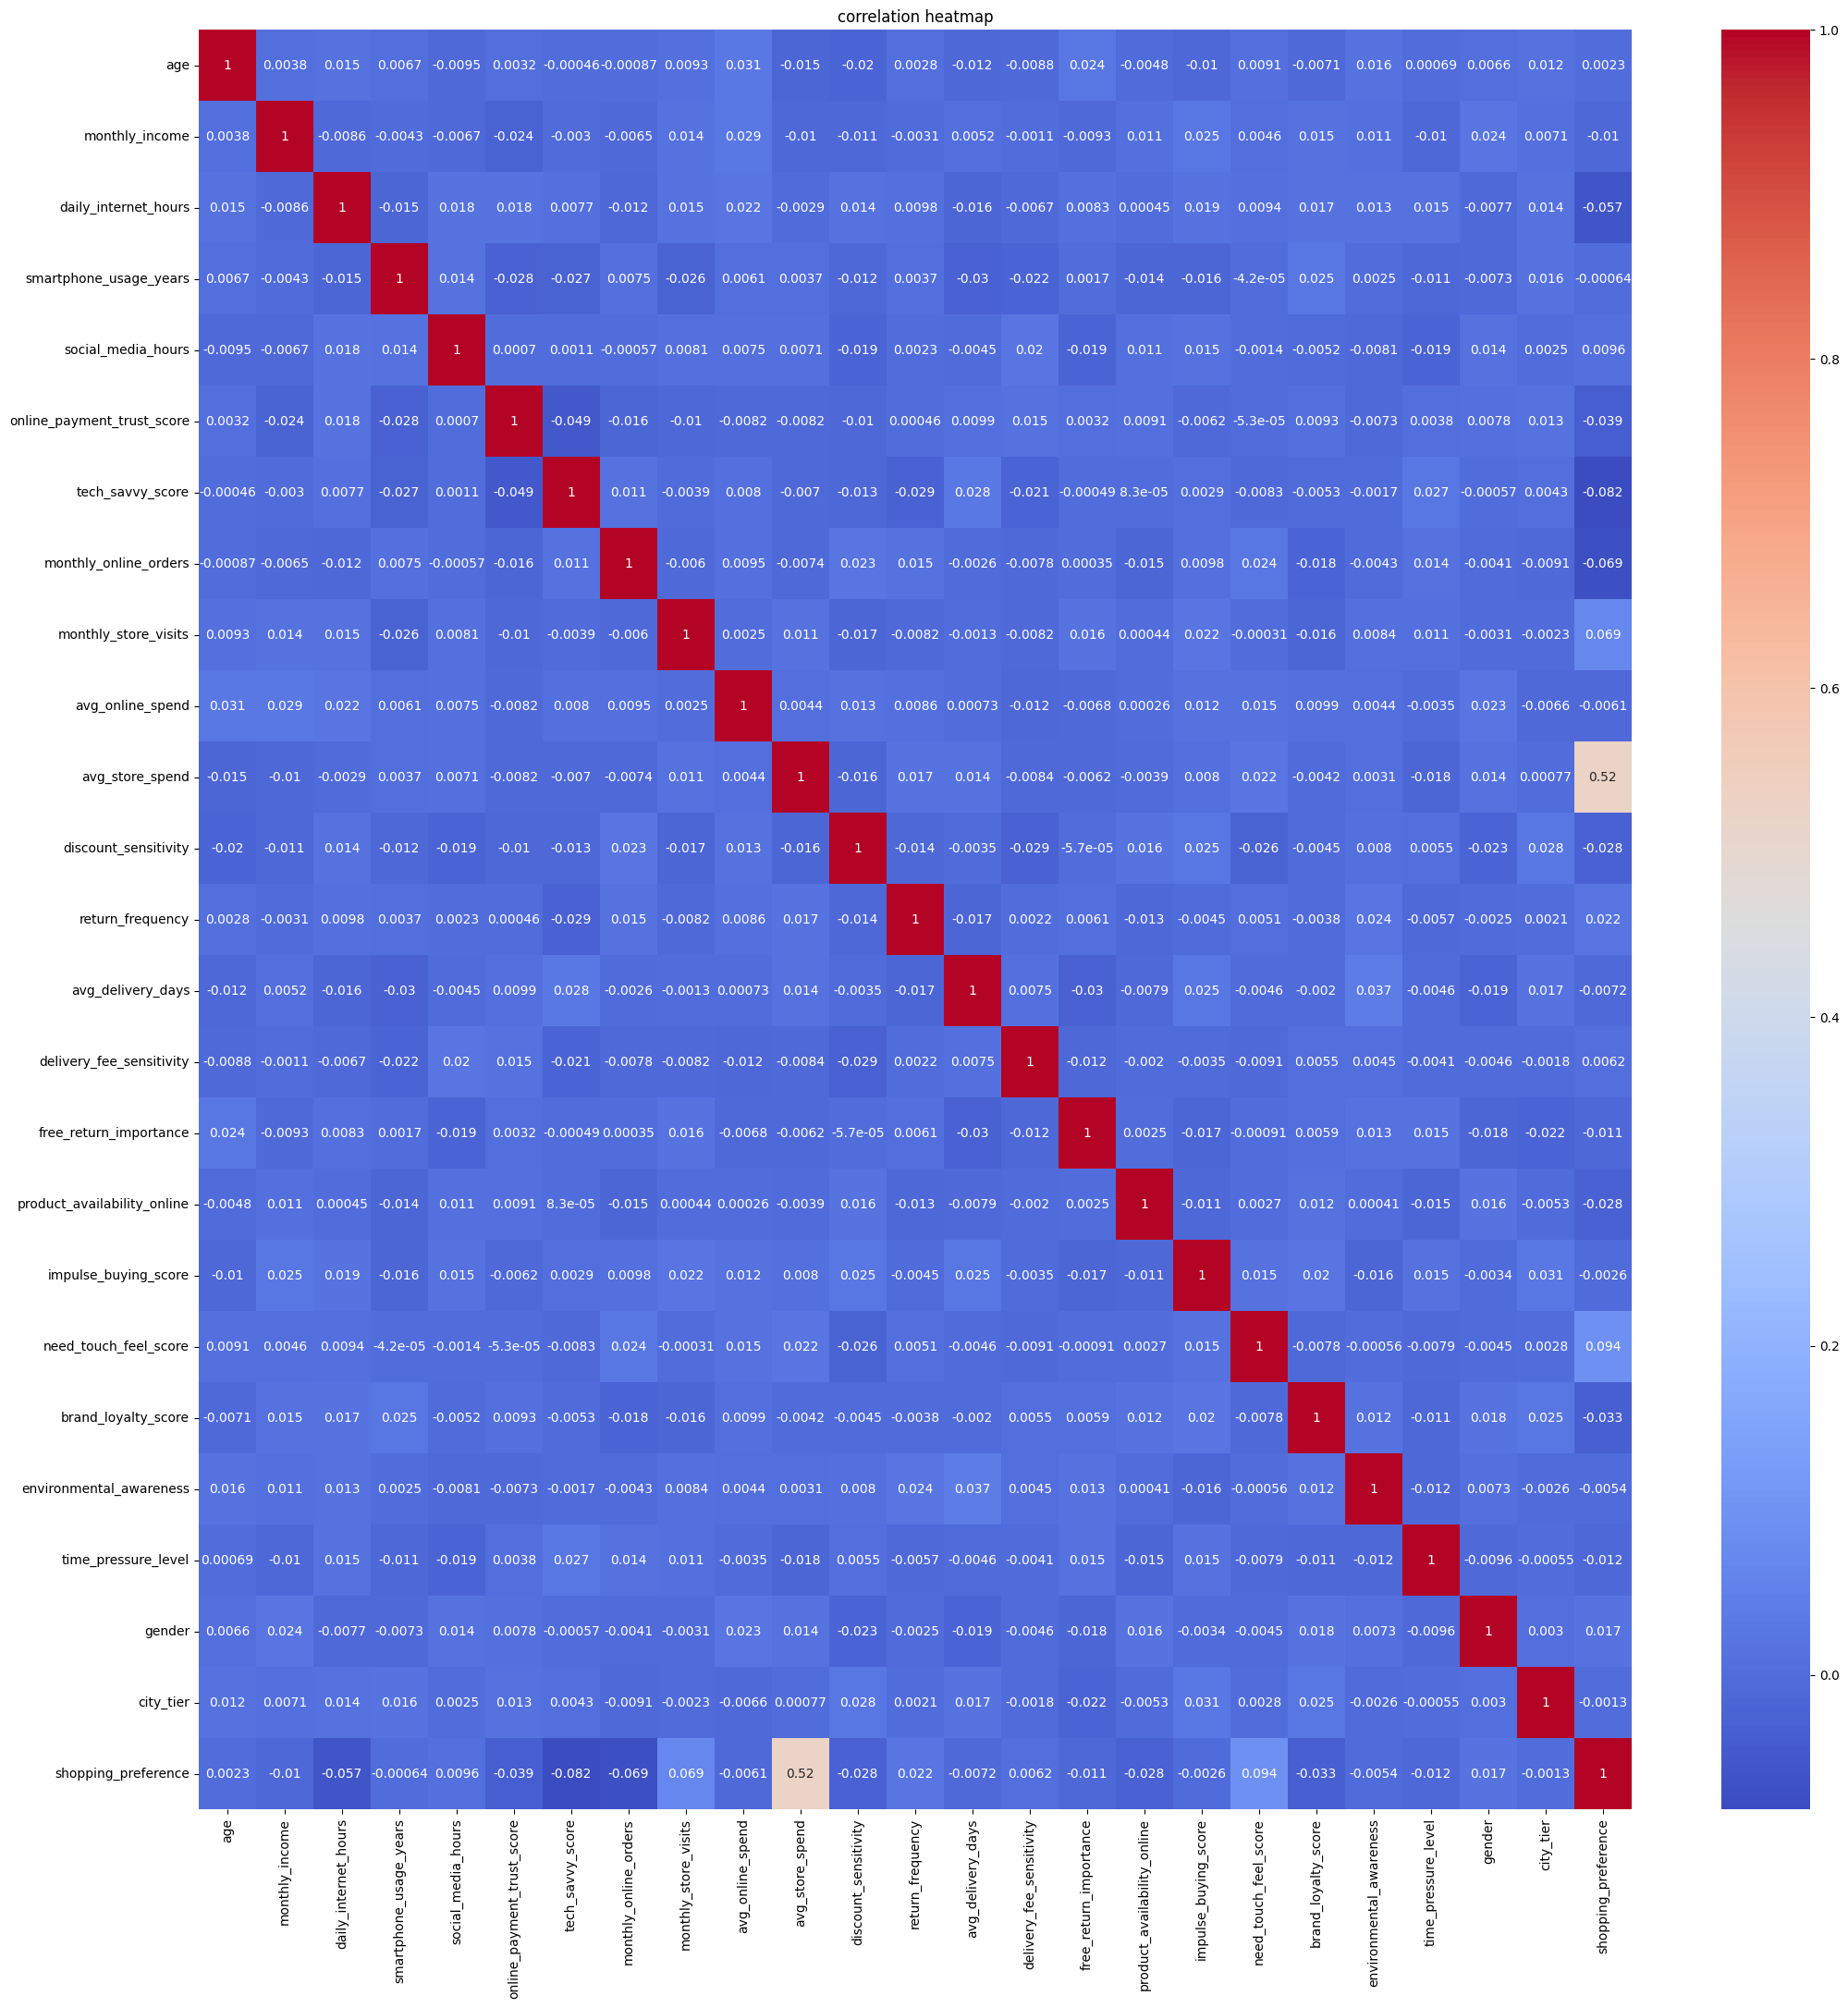

In [20]:
plt.figure(figsize=(25,25))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("correlation heatmap")
plt.show()

In [21]:
corr_matrix = df.corr()
corr_with_target = corr_matrix['shopping_preference'].sort_values(ascending=False)
print(corr_with_target)

shopping_preference            1.000000
avg_store_spend                0.524488
need_touch_feel_score          0.093608
monthly_store_visits           0.068803
return_frequency               0.021825
gender                         0.017349
social_media_hours             0.009638
delivery_fee_sensitivity       0.006199
age                            0.002292
smartphone_usage_years        -0.000636
city_tier                     -0.001261
impulse_buying_score          -0.002577
environmental_awareness       -0.005427
avg_online_spend              -0.006106
avg_delivery_days             -0.007212
monthly_income                -0.010379
free_return_importance        -0.010554
time_pressure_level           -0.011915
product_availability_online   -0.027917
discount_sensitivity          -0.028051
brand_loyalty_score           -0.032598
online_payment_trust_score    -0.038537
daily_internet_hours          -0.056826
monthly_online_orders         -0.069280
tech_savvy_score              -0.081726


**EXTRACT FEATURES AND TARGET VARIABLE**

In [22]:
selected_features = ['avg_store_spend','need_touch_feel_score','monthly_store_visits','return_frequency','online_payment_trust_score','daily_internet_hours','monthly_online_orders','tech_savvy_score','brand_loyalty_score','discount_sensitivity','product_availability_online']
x=df[selected_features]
y=df['shopping_preference']

In [23]:
x

,avg_store_spend,need_touch_feel_score,monthly_store_visits,return_frequency,online_payment_trust_score,daily_internet_hours,monthly_online_orders,tech_savvy_score,brand_loyalty_score,discount_sensitivity,product_availability_online
0,144092,3,16,3,1,6.5,16,6,6,2,7
1,28421,6,1,7,6,8.2,14,9,8,4,4
2,128229,1,0,4,10,6.4,2,8,3,9,10
3,134650,8,3,0,2,6.4,20,10,2,7,2
4,34122,9,16,9,2,6.0,18,5,7,5,5
...,...,...,...,...,...,...,...,...,...,...,...
4995,13760,4,7,3,10,8.6,1,2,5,8,3
4996,23033,10,7,2,7,6.0,0,8,1,9,7
4997,31804,8,6,6,5,5.6,13,4,1,8,1
4998,28241,1,9,2,5,2.9,43,6,8,10,9


In [24]:
y

,shopping_preference
0,2
1,0
2,2
3,2
4,2
...,...
4995,0
4996,2
4997,2
4998,1


**FEATURE SCALING**

In [25]:
scaler=MinMaxScaler()
x_scaled=scaler.fit_transform(x)
x_scaled

array([[0.96064468, 0.22222222, 0.84210526, ..., 0.55555556, 0.11111111,
        0.66666667],
       [0.18644919, 0.55555556, 0.05263158, ..., 0.77777778, 0.33333333,
        0.33333333],
       [0.85447232, 0.        , 0.        , ..., 0.22222222, 0.88888889,
        1.        ],
       ...,
       [0.20909188, 0.77777778, 0.31578947, ..., 0.        , 0.77777778,
        0.        ],
       [0.18524443, 0.        , 0.47368421, ..., 0.77777778, 1.        ,
        0.88888889],
       [0.0402455 , 0.        , 0.05263158, ..., 0.11111111, 1.        ,
        0.77777778]])

**DATA SPLITTING**

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

**MODEL CREATION**

In [27]:
knn=KNeighborsClassifier(n_neighbors=3)
svc=SVC()
nb=GaussianNB()
dt=DecisionTreeClassifier()
rf=RandomForestClassifier()
ada=AdaBoostClassifier()
gb=GradientBoostingClassifier()

In [28]:
Model=[knn,svc,nb,dt,rf,ada,gb]
for model in Model:
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  print(model)
  print(accuracy_score(y_test,y_pred)*100)
  print(classification_report(y_test,y_pred))
  print('--------------------------------------------------------------')

KNeighborsClassifier(n_neighbors=3)
90.4
              precision    recall  f1-score   support

           0       0.08      0.10      0.09        40
           1       0.70      0.62      0.66       152
           2       0.96      0.96      0.96      1308

    accuracy                           0.90      1500
   macro avg       0.58      0.56      0.57      1500
weighted avg       0.91      0.90      0.91      1500

--------------------------------------------------------------
SVC()
92.46666666666667
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        40
           1       0.67      0.73      0.70       152
           2       0.96      0.98      0.97      1308

    accuracy                           0.92      1500
   macro avg       0.54      0.57      0.55      1500
weighted avg       0.90      0.92      0.91      1500

--------------------------------------------------------------
GaussianNB()
95.8
              precision    re

**DECISION TREE**

In [29]:
dt=DecisionTreeClassifier(criterion='entropy')
dt.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

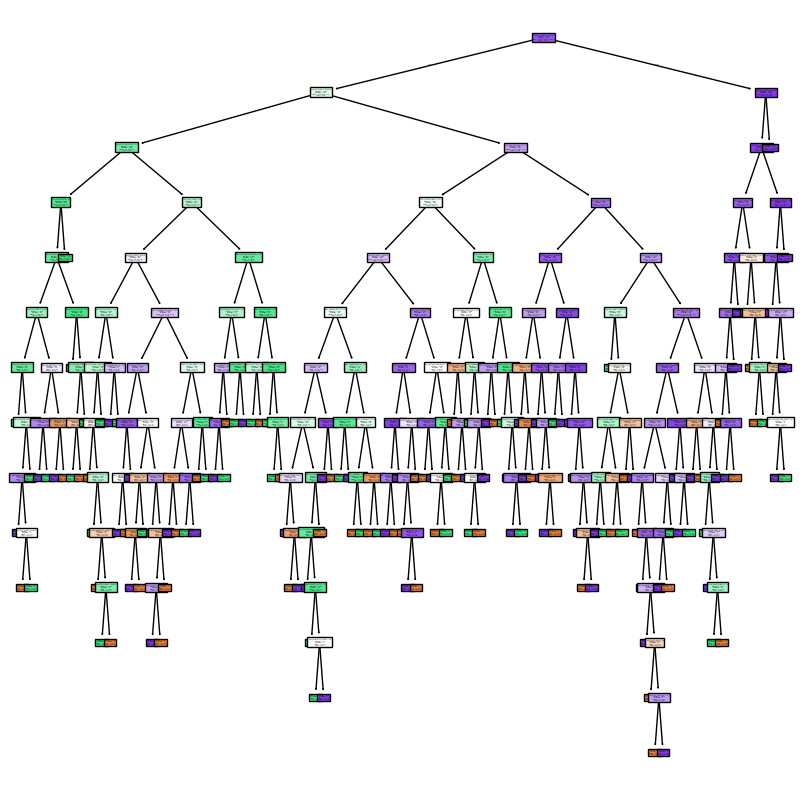

In [30]:
plt.figure(figsize=(10,10))
tree.plot_tree(dt,filled=True,feature_names=['avg_store_spend','need_touch_feel_score','monthly_store_visits','return_frequency','online_payment_trust_score','daily_internet_hours','monthly_online_orders','tech_savvy_score','brand_loyalty_score','discount_sensitivity','product_availability_online'],class_names=['Hybrid','Store','Online'])
plt.show()

**HANDLING IMBALANCED DATA**

In [31]:
df['shopping_preference'].value_counts()

,count
shopping_preference,
2,4323
1,521
0,156


In [32]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()
x_smote,y_smote=smote.fit_resample(x,y)

In [33]:
x_smote.shape,y_smote.shape

((12969, 11), (12969,))

In [34]:
y_smote.value_counts()

,count
shopping_preference,
2,4323
0,4323
1,4323


In [35]:
x_smote_scaled=scaler.fit_transform(x_smote)
x_smote_train,x_smote_test,y_smote_train,y_smote_test=train_test_split(x_smote_scaled,y_smote,test_size=0.3,random_state=1)

In [36]:
knn1=KNeighborsClassifier(n_neighbors=3)
svc1=SVC()
nb1=GaussianNB()
dt1=DecisionTreeClassifier()
rf1=RandomForestClassifier()
ada1=AdaBoostClassifier()
gb1=GradientBoostingClassifier()

In [37]:
Model1=[knn1,svc1,nb1,dt1,rf1,ada1,gb1]
for model in Model1:
  model.fit(x_smote_train,y_smote_train)
  y_smote_pred=model.predict(x_smote_test)
  print(model)
  print(accuracy_score(y_smote_test,y_smote_pred)*100)
  print(classification_report(y_smote_test,y_smote_pred))
  print('--------------------------------------------------------------')

KNeighborsClassifier(n_neighbors=3)
90.43947571318427
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      1284
           1       0.90      0.96      0.93      1272
           2       1.00      0.77      0.87      1335

    accuracy                           0.90      3891
   macro avg       0.91      0.91      0.90      3891
weighted avg       0.92      0.90      0.90      3891

--------------------------------------------------------------
SVC()
98.22667694680031
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1284
           1       1.00      0.99      0.99      1272
           2       1.00      0.96      0.98      1335

    accuracy                           0.98      3891
   macro avg       0.98      0.98      0.98      3891
weighted avg       0.98      0.98      0.98      3891

--------------------------------------------------------------
GaussianNB()
86.37882292469801
   

**HYPER PARAMETER TUNING**

In [38]:
models = {
    "KNN": (KNeighborsClassifier(),{"n_neighbors": [3, 5, 7, 9],"weights": ['uniform', 'distance'],"metric": ['euclidean', 'manhattan']}),
    "Random Forest": (RandomForestClassifier(),{"n_estimators": [50, 100, 150],"max_depth": [5, 10, 15],"min_samples_split": [2, 5],"min_samples_leaf": [1, 2]}),
    "Decision Tree": (DecisionTreeClassifier(),{"max_depth": [5, 10, 15],"criterion": ['gini', 'entropy'],"min_samples_split": [2, 5],"min_samples_leaf": [1, 2]}),
    "GaussianNB": (GaussianNB(),{"var_smoothing": [1e-9, 1e-8, 1e-7]}),
    "AdaBoost": (AdaBoostClassifier(),{"n_estimators": [50, 100, 150],"learning_rate": [0.01, 0.1, 1]}),
    "Gradient Boost": (GradientBoostingClassifier(),{"n_estimators": [50, 100, 150],"learning_rate": [0.01, 0.1],"max_depth": [3, 5],"subsample": [0.8, 1.0]}),
    "SVC":(SVC(),{"C": [0.1, 1, 10],"kernel": ['linear', 'rbf', 'poly'],"gamma": ['scale', 'auto']})
    }

for name, (model, params) in models.items():
  grid = GridSearchCV(model,params,cv=5,scoring='accuracy')
  grid.fit(x_smote_train, y_smote_train)

  print("\n", name)
  print("Best Parameters:", grid.best_params_)
  print("Best Accuracy:", grid.best_score_)


 KNN
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best Accuracy: 0.9044954551522432

 Random Forest
Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Best Accuracy: 0.9764263176417762

 Decision Tree
Best Parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Accuracy: 0.947896081358236

 GaussianNB
Best Parameters: {'var_smoothing': 1e-09}
Best Accuracy: 0.8642871445734881

 AdaBoost
Best Parameters: {'learning_rate': 1, 'n_estimators': 150}
Best Accuracy: 0.8639574155653451

 Gradient Boost
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150, 'subsample': 0.8}
Best Accuracy: 0.9840272569507651

 SVC
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'poly'}
Best Accuracy: 0.9911871821943908


**COMPARE TRAINING AND TESTING ACCURACY**

In [39]:
train_accuracy = svc1.score(x_smote_train, y_smote_train)
test_accuracy = svc1.score(x_smote_test, y_smote_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9857898215465961
Testing Accuracy: 0.9822667694680031


**TESTING THE SVC MODEL**

In [40]:
new_data = [[13760,4,7,3,10,8.6,1,2,5,8,3]]
new_data_scaled = scaler.transform(new_data)

prediction = svc1.predict(new_data_scaled)
print("Predicted Class:", prediction)

Predicted Class: [0]


**CONCLUSION**

This project analyzed customer behavior using the **Online vs In-Store Shopping Dataset** to understand shopping preferences and predict whether customers prefer Online, Store, or Hybrid shopping. Different machine learning models such as KNN, SVC, Random Forest, Decision Tree, GaussianNB, AdaBoost, and Gradient Boosting were implemented and compared.

*   The dataset was found to be imbalanced, with the majority of customers
preferring Store Shopping. To address this issue, **SMOTE (Synthetic Minority
Over Sampling Technique)** was applied to balance the classes and improve model performance. Feature selection and correlation analysis were also performed to identify the most influential factors affecting shopping behavior.

*   Hyperparameter tuning was carried out using GridSearchCV to optimize model performance. After evaluation using accuracy, classification report, and confusion matrix, **SVC with accuracy 99.11% was the best performing model** based on overall prediction accuracy.


*   Training and testing accuracy were compared to check the model’s generalization performance. Since both accuracies were very close, the SVC model showed minimal overfitting and performed well on unseen data.



The analysis showed that factors such as internet usage, online spending, discount sensitivity, trust in online payments, and shopping habits play an important role in determining customer shopping preferences. This project demonstrates how machine learning can be effectively used to analyze consumer behavior and help businesses make data-driven decisions to improve both online and offline shopping experiences.


*Dataset Source : https://www.kaggle.com/datasets/shree0910/online-vs-in-store-shopping-behaviour-dataset*